# HMM and AR(1) models, exploration and simulation

## **Part 1** Simulating and plotting data

Simulation code provided by Gudmund (advisor)

In [12]:
import numpy as np

np.random.seed(1)

T = 500

# AR(1) parameters
rho = np.array([0.2, 0.8])
sigma = np.array([0.5, 1.0])

# transition matrix
P = np.array([
    [0.95, 0.05],
    [0.05, 0.95]
])

states = np.zeros(T, dtype=int)
y = np.zeros(T)

# initial values
states[0] = np.random.choice([0,1])
y[0] = np.random.normal()

for t in range(1, T):

    # simulate next state
    states[t] = np.random.choice([0,1], p=P[states[t-1]])

    # simulate observation
    s = states[t]
    y[t] = rho[s]*y[t-1] + np.random.normal(scale=sigma[s])

### Plotting the simulated AR(1) series

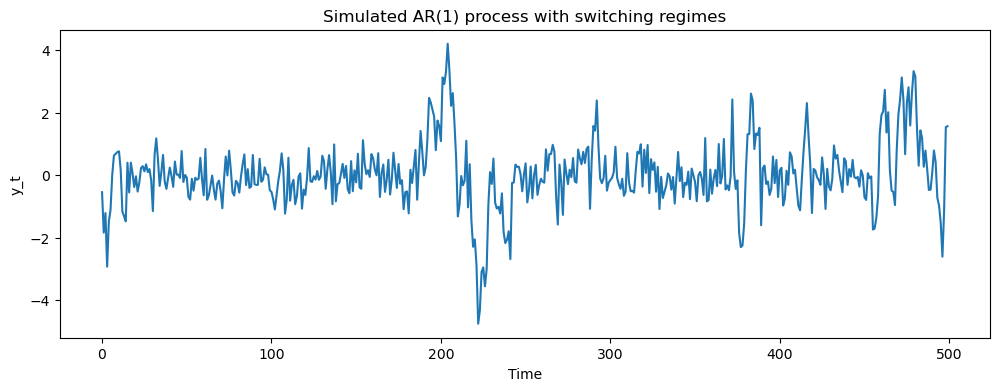

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(y)
plt.title("Simulated AR(1) process with switching regimes")
plt.xlabel("Time")
plt.ylabel("y_t")
plt.show()

### Plotting the hidden states

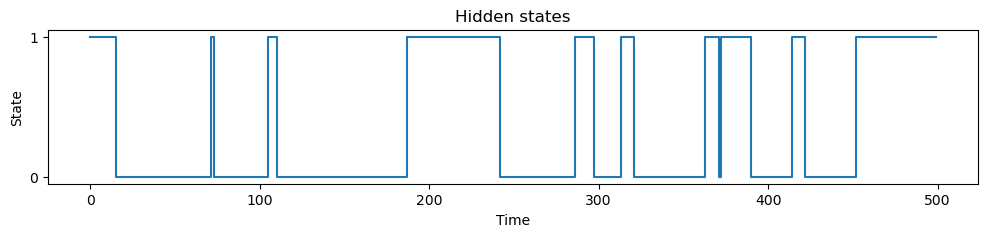

In [14]:
plt.figure(figsize=(12,2))
plt.step(range(T), states, where="post")
plt.title("Hidden states")
plt.xlabel("Time")
plt.ylabel("State")
plt.yticks([0,1])
plt.show()

### Combined plot

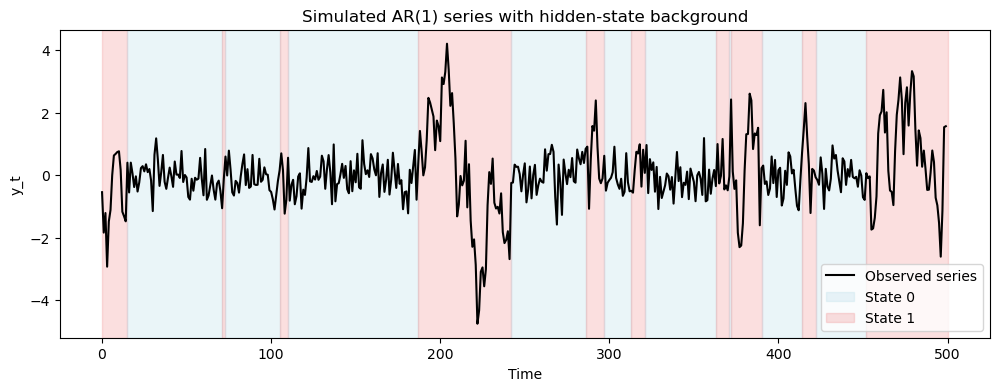

In [15]:
import matplotlib.patches as mpatches

state_colors = {
    0: "lightblue",
    1: "lightcoral"
}

plt.figure(figsize=(12, 4))
plt.plot(y, color="black", linewidth=1.5, label="Observed series")

start = 0
current_state = states[0]

for t in range(1, T):
    if states[t] != current_state:
        plt.axvspan(start, t, color=state_colors[current_state], alpha=0.25)
        start = t
        current_state = states[t]

plt.axvspan(start, T, color=state_colors[current_state], alpha=0.25)

legend_patches = [
    mpatches.Patch(color=state_colors[0], alpha=0.25, label="State 0"),
    mpatches.Patch(color=state_colors[1], alpha=0.25, label="State 1")
]

plt.legend(handles=[plt.Line2D([0], [0], color="black", label="Observed series")] + legend_patches)
plt.title("Simulated AR(1) series with hidden-state background")
plt.xlabel("Time")
plt.ylabel("y_t")
plt.show()

### Simulation of a Regime-Switching AR(1) Process, summary

The code simulates a time series generated by an **AR(1) process whose parameters depend on an unobserved (hidden) state**. The hidden state evolves according to a **two-state Markov chain**.

First, two sets of AR(1) parameters are defined. Each state has its own autoregressive coefficient \( $\rho$ \) and innovation standard deviation \( $\sigma$ \). A **transition matrix** specifies the probability of switching between the two states at each time step.

The simulation proceeds recursively for \(T = 500\) observations. At each time step:

1. The next hidden state is drawn using the transition probabilities of the Markov chain.
2. Conditional on the current state, the observation is generated from the corresponding AR(1) model:
$$
y_t = \rho_s y_{t-1} + \varepsilon_t, \quad \varepsilon_t \sim N(0, \sigma_s^2)
$$

This produces two sequences:
- `states`: the simulated hidden regimes
- `y`: the observed time series

After running the simulation, the resulting AR(1) series is plotted. The background of the plot is shaded according to the hidden state, making it possible to visually identify the periods in which the process is governed by each regime.

## **Part 2** Estimate parameters using MLE and forward algorithm